# Module 6 EDA Project
**Author:** Kim Melso

**Date:** February 2026

### DataSet: Seaborn Planets
* Description: Data on 1,035 exoplanets discovered up to 2014
* Access: Available via Seaborn's built in datasets

### Section 1: Data imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("Imports complete.")

Imports complete.


### Section 2: Load Data Set

In [2]:
# Load the planets dataset
planets = sns.load_dataset('planets')

# List column names
print(planets.columns)

# Inspect first few rows of the DataFrame
print(planets.head())

Index(['method', 'number', 'orbital_period', 'mass', 'distance', 'year'], dtype='str')
            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


### Section 3: Initial Data Inspections

In [13]:
# Get shape - number of rows and columns
shape: tuple[int, int] = planets.shape

# Communicate the shape clearly
print(f"The planets dataset has {shape[0]} rows and {shape[1]} columns.")

The planets dataset has 1035 rows and 6 columns.


In [14]:
# Display column names and data types
planets.info()

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   str    
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 60.5 KB


### Section 4: Quality Check and Clean View for EDA

In [15]:
# Count missing values in each column
print("Missing values per column:")
print(planets.isnull().sum())

# Check for duplicates
num_duplicates = planets.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Missing values per column:
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64
Number of duplicate rows: 4


In [16]:
# Create a clean view by dropping rows with any missing values
planets_clean: pd.DataFrame = planets.dropna()

# Compare sizes
print(f"Original dataset: {len(planets)} rows")
print(f"Clean dataset: {len(planets_clean)} rows")
print(f"Rows removed: {len(planets) - len(planets_clean)}")

Original dataset: 1035 rows
Clean dataset: 498 rows
Rows removed: 537


### Section 5: Initial Descriptive Statistics

In [17]:
print(planets_clean.describe())

          number  orbital_period        mass    distance         year
count  498.00000      498.000000  498.000000  498.000000   498.000000
mean     1.73494      835.778671    2.509320   52.068213  2007.377510
std      1.17572     1469.128259    3.636274   46.596041     4.167284
min      1.00000        1.328300    0.003600    1.350000  1989.000000
25%      1.00000       38.272250    0.212500   24.497500  2005.000000
50%      1.00000      357.000000    1.245000   39.940000  2009.000000
75%      2.00000      999.600000    2.867500   59.332500  2011.000000
max      6.00000    17337.500000   25.000000  354.000000  2014.000000


### Section 6: Intitial Data Distribution
*This graph shows the number of expoplanets discovered overtime using the clean data set

<Axes: xlabel='year', ylabel='Count'>

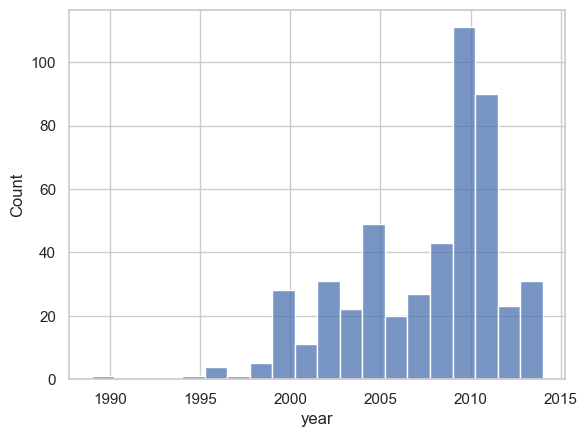

In [18]:
sns.histplot(data=planets_clean, x="year", bins=20)

### Section 7: Additional Plots
* Detection Method Comparison (using full data set)
* Distance of detected plantet by decade (using full data set)
* Mass Distribution (using clean data)
* Mass vs. Orbital Period by detection method (using full data set)
* Correlation heat map (using clean data)

The plots that involved detection methods used the full data set as many of those rows were removed in the clean data.

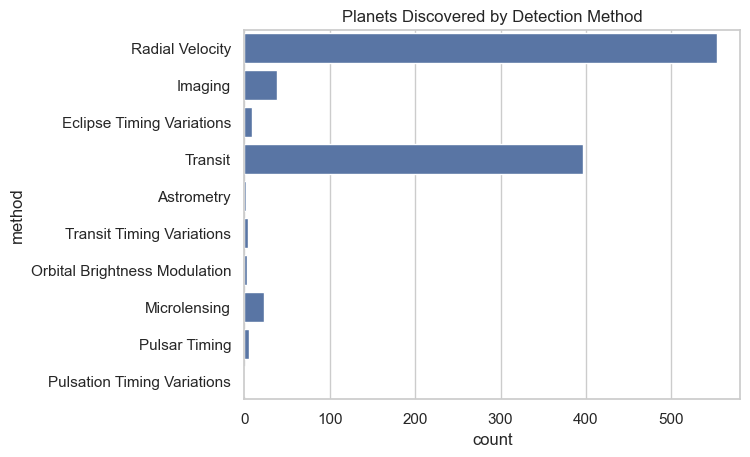

In [21]:
sns.countplot(data=planets, y="method")
plt.title("Planets Discovered by Detection Method")
plt.show()

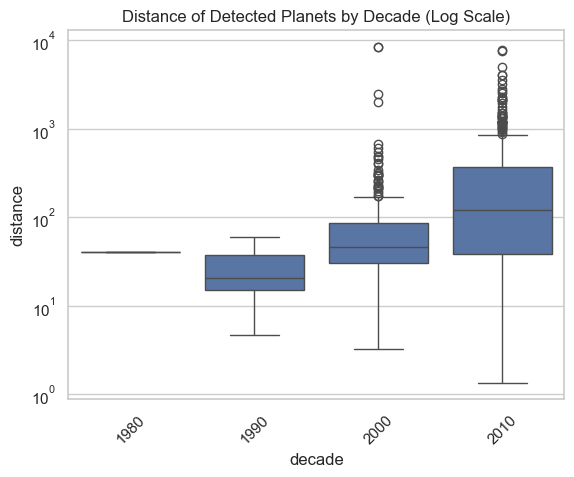

In [31]:
planets["decade"] = (planets["year"] // 10) * 10

sns.boxplot(data=planets, x="decade", y="distance")
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Distance of Detected Planets by Decade (Log Scale)")
plt.show()

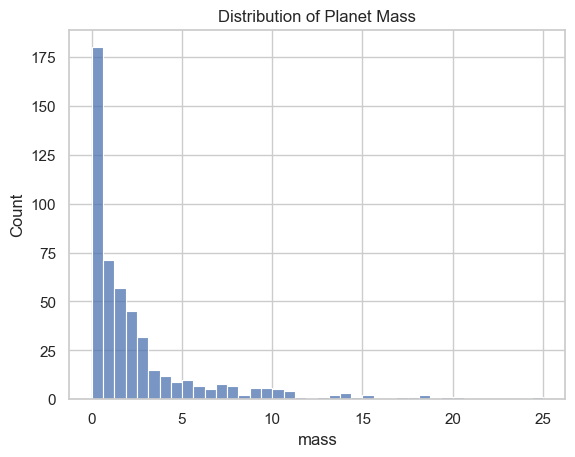

In [40]:
sns.histplot(planets_clean["mass"].dropna(), bins=40)
plt.title("Distribution of Planet Mass")
plt.show()

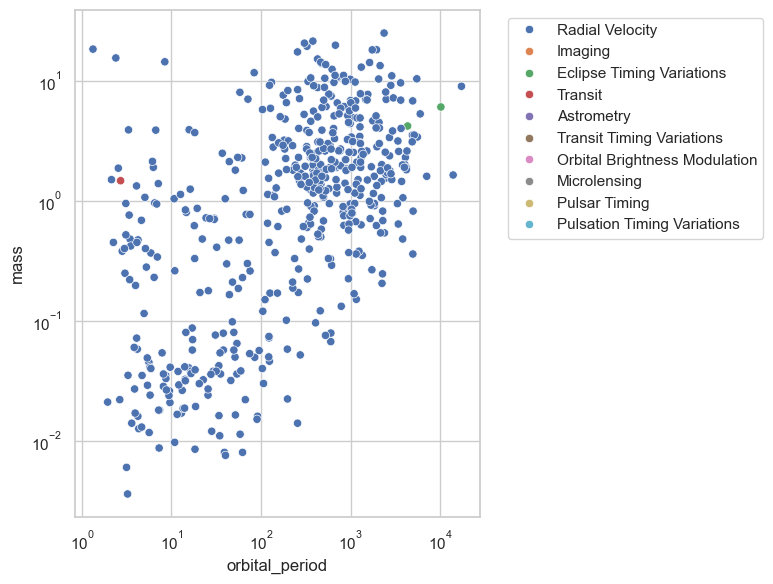

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=planets,
                x="orbital_period",
                y="mass",
                hue="method")

plt.xscale("log")
plt.yscale("log")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

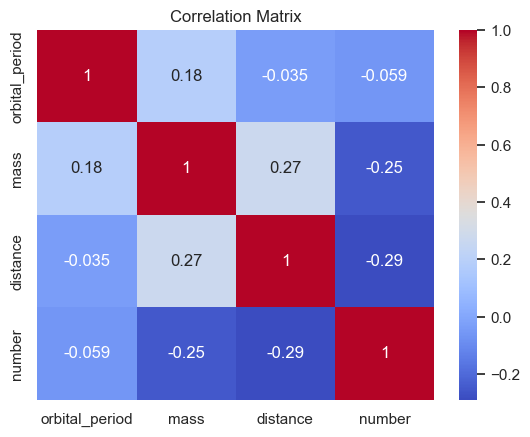

In [33]:
corr = planets_clean[["orbital_period", "mass", "distance", "number"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Section 8: Summary from EDA

Exploratory analysis of the planets dataset reveals a sharp increase in discoveries beginning around 2009. The Transit and Radial Velocity methods account for the majority of discoveries. These methods of discovery tended to discover 

Several key variables such as mass, orbital period, and distance required using a log scale on the axes to improve the visualization of these plots and allow patterns to emerge. Although the data seems to show a lot of low mass expoplanet discovires, the method of radial velocity detection actually found many more higher mass expoplanets as seen in the scatterplot

